# 1 Importing and Merging Dataset

In [ ]:
# import pandas as pd
# from pathlib import Path

# folder = Path(r"C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs")

# dfs = []

# for file in folder.glob("*.csv"):
#     print("Loading:", file)
#     dfs.append(pd.read_csv(file))

# print("Loaded files:", len(dfs))

Loading: C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs\2026-06-03.csv
Loading: C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs\2026-06-04.csv
Loaded files: 2


In [ ]:
# all_df = pd.concat(dfs, ignore_index=True)

# print(all_df.shape)
# corr = all_df.corr(numeric_only=True)
# print(corr)

(2880, 10)
                    stress  body_battery  respiration_rate  heart_rate  \
stress            1.000000     -0.050002         -0.023885    0.108275   
body_battery     -0.050002      1.000000         -0.079695   -0.079729   
respiration_rate -0.023885     -0.079695          1.000000   -0.002904   
heart_rate        0.108275     -0.079729         -0.002904    1.000000   
intensity         0.195886      0.286027          0.170457   -0.116811   
cycles           -0.014748      0.181579          0.192490   -0.243765   
active_time      -0.026837      0.171302          0.201297   -0.252885   
active_calories  -0.024560      0.165803          0.200704   -0.242878   

                  intensity    cycles  active_time  active_calories  
stress             0.195886 -0.014748    -0.026837        -0.024560  
body_battery       0.286027  0.181579     0.171302         0.165803  
respiration_rate   0.170457  0.192490     0.201297         0.200704  
heart_rate        -0.116811 -0.243765    -

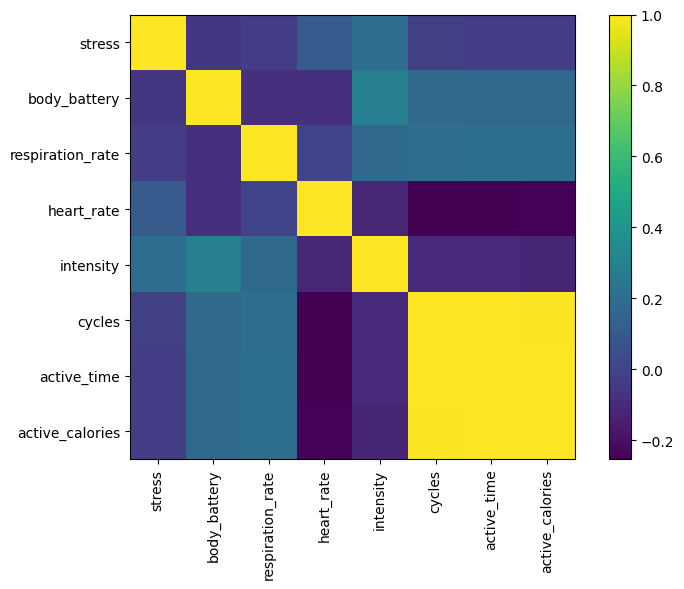

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.imshow(corr)
# plt.colorbar()
# plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
# plt.yticks(range(len(corr.columns)), corr.columns)
# plt.tight_layout()
# plt.show()

In [ ]:
# print(all_df.shape)
# print(all_df.info())

(2880, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         2880 non-null   str    
 1   stress            2515 non-null   float64
 2   body_battery      2746 non-null   float64
 3   respiration_rate  2300 non-null   float64
 4   heart_rate        1892 non-null   float64
 5   activity_type     151 non-null    str    
 6   intensity         151 non-null    float64
 7   cycles            151 non-null    float64
 8   active_time       151 non-null    float64
 9   active_calories   151 non-null    float64
dtypes: float64(8), str(2)
memory usage: 225.1 KB
None


In [ ]:
# all_df.isnull().sum()

timestamp              0
stress               365
body_battery         134
respiration_rate     580
heart_rate           988
activity_type       2729
intensity           2729
cycles              2729
active_time         2729
active_calories     2729
dtype: int64

In [ ]:
# all_df.describe()

,stress,body_battery,respiration_rate,heart_rate,intensity,cycles,active_time,active_calories
count,2515.000000,2746.000000,2300.000000,1892.000000,151.000000,151.000000,151.000000,151.000000
mean,23.233797,54.357975,14.473139,70.485729,2.940397,3332.470199,3745.728477,225.417219
std,23.015236,21.274416,2.495619,14.521790,1.822935,2773.915602,2987.587481,176.766866
min,-2.000000,21.000000,0.000000,44.000000,0.000000,0.000000,4.000000,0.000000
25%,7.000000,37.000000,12.910000,59.000000,2.000000,298.250000,612.500000,37.500000
50%,17.000000,51.000000,14.720000,68.000000,2.000000,3108.000000,3628.000000,228.000000
75%,34.000000,72.000000,16.000000,79.000000,4.000000,5624.000000,6215.000000,374.000000
max,98.000000,95.000000,21.750000,135.000000,7.000000,8623.000000,8866.000000,495.000000


<Axes: >

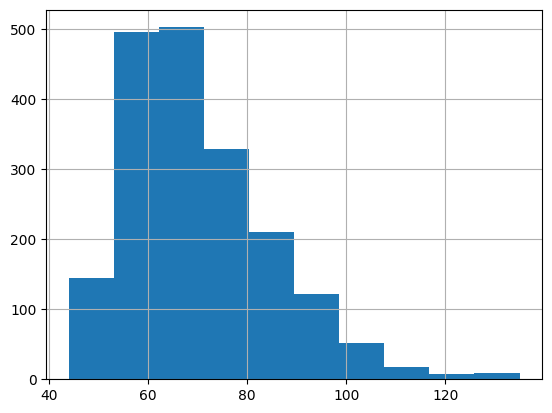

In [ ]:
# all_df["heart_rate"].hist()

<Axes: >

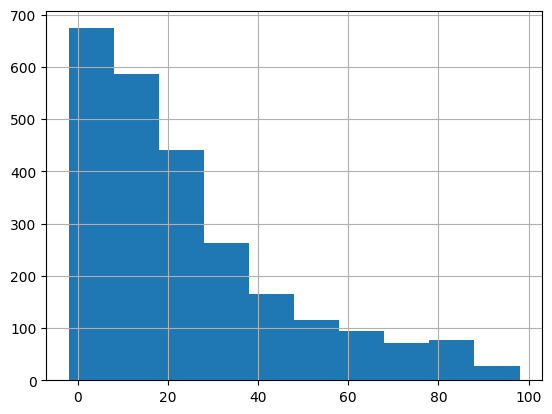

In [ ]:
# all_df["stress"].hist()

# EDA (with full_df)

In [3]:
import pandas as pd
from fitparse import FitFile
from collections import Counter
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

#eda1: Dataset overview:

In [32]:

full_df = pd.read_csv("../final_dfs/full_df.csv")

# Inspection of structure, types, and sample rows
print(full_df.shape)
print(full_df.info())
print(full_df.head())


(4320, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         4320 non-null   object 
 1   stress            3775 non-null   float64
 2   body_battery      4107 non-null   float64
 3   respiration_rate  3462 non-null   float64
 4   heart_rate        3515 non-null   float64
 5   activity_type     4138 non-null   object 
 6   is_cognitive      4320 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 236.4+ KB
None
             timestamp  stress  body_battery  respiration_rate  heart_rate  \
0  2026-06-03 00:00:00     NaN           NaN               NaN         NaN   
1  2026-06-03 00:01:00    12.0          32.0             13.58         NaN   
2  2026-06-03 00:02:00    20.0          32.0             15.36        64.0   
3  2026-06-03 00:03:00     NaN           NaN             14.91        74.0   
4 

#EDA2: checking for missing val: We assess data completeness to understand sensor reliability and potential bias in physiological signals.

In [33]:

val_missing = (full_df.isna().sum().sort_values(ascending=False))
print(val_missing)

respiration_rate    858
heart_rate          805
stress              545
body_battery        213
activity_type       182
timestamp             0
is_cognitive          0
dtype: int64


In [34]:
# Converting nan counts into percentages for interpretability
missing_pct = (full_df.isna().mean() * 100).round(2)
print(missing_pct)

timestamp            0.00
stress              12.62
body_battery         4.93
respiration_rate    19.86
heart_rate          18.63
activity_type        4.21
is_cognitive         0.00
dtype: float64


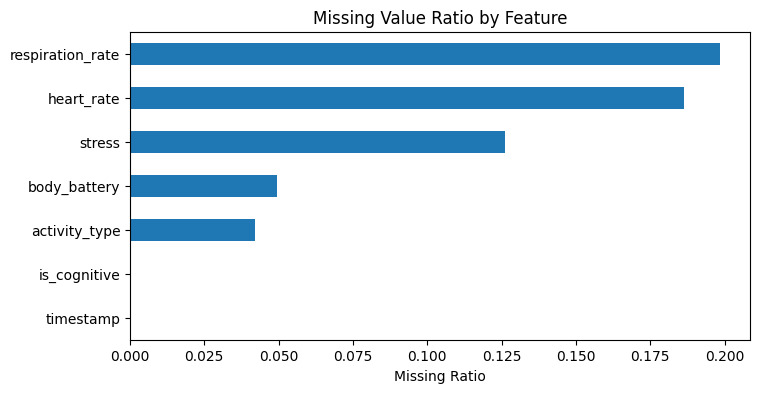

In [35]:
# plotting missingness across features
missing_ratio = full_df.isna().mean().sort_values()

plt.figure(figsize=(8, 4))
missing_ratio.plot(kind="barh")
plt.title("Missing Value Ratio by Feature")
plt.xlabel("Missing Ratio")
plt.show()

EDA3: checking for class imbalance: We evaluate class imbalance since cognitive periods represent a minority of the dataset.

In [36]:
# checking the distribution of cognitive vs non cognitive mins
full_df["is_cognitive"].value_counts()

is_cognitive
0    3483
1     837
Name: count, dtype: int64

In [37]:
#Normalizing class distribution to check imbalance
full_df["is_cognitive"].value_counts(normalize=True)

is_cognitive
0    0.80625
1    0.19375
Name: proportion, dtype: float64

Feature Overview: We summarize physiological variables to understand baseline ranges and variability.

In [38]:
#EDA4: checking for physiological variables
physiological_features = [
    "stress",
    "body_battery",
    "heart_rate",
    "respiration_rate"
]
full_df[physiological_features].describe()

,stress,body_battery,heart_rate,respiration_rate
count,3775.000000,4107.000000,3515.000000,3462.000000
mean,24.243709,56.219382,71.916074,14.403917
std,24.014899,21.855631,16.747873,2.509860
min,-2.000000,21.000000,46.000000,0.000000
25%,7.000000,37.000000,59.000000,13.000000
50%,18.000000,54.000000,68.000000,14.630000
75%,35.000000,75.000000,81.000000,16.000000
max,99.000000,97.000000,155.000000,22.080000


Distribution Analysis: We visually compare distributions of physiological signals between cognitive and non-cognitive periods.

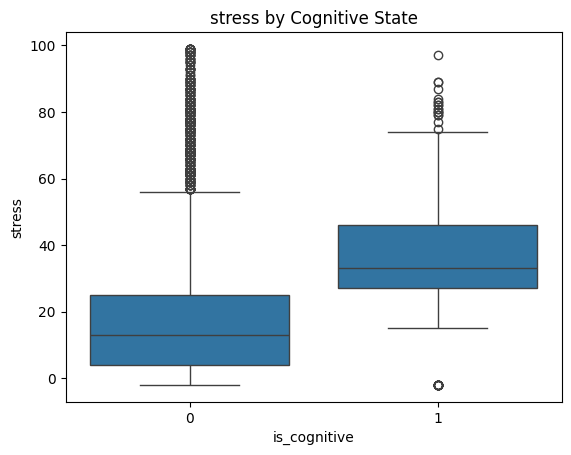

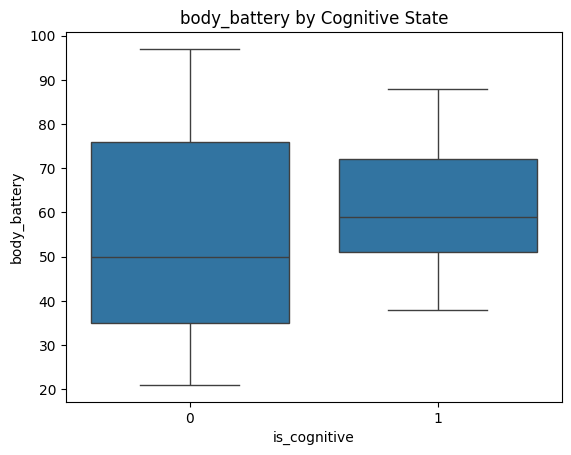

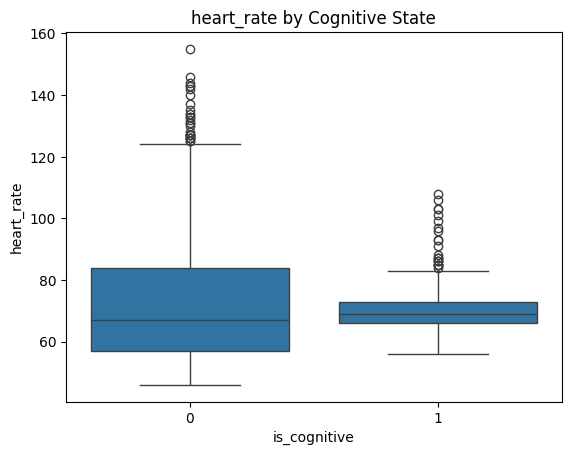

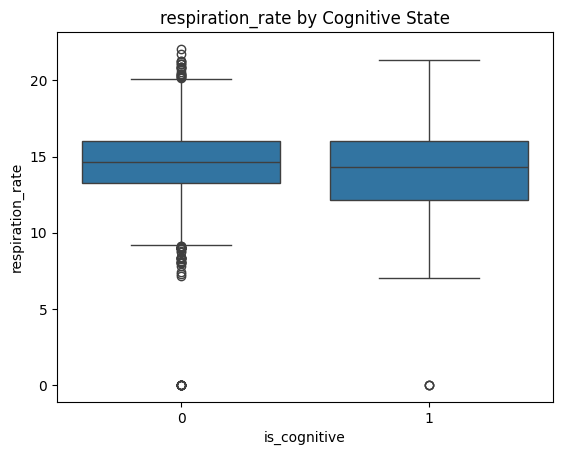

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

features = physiological_features

# Compare distributions across cognitive states
for col in features:
    plt.figure()
    sns.boxplot(data=full_df, x="is_cognitive", y=col)
    plt.title(f"{col} by Cognitive State")
    plt.show()

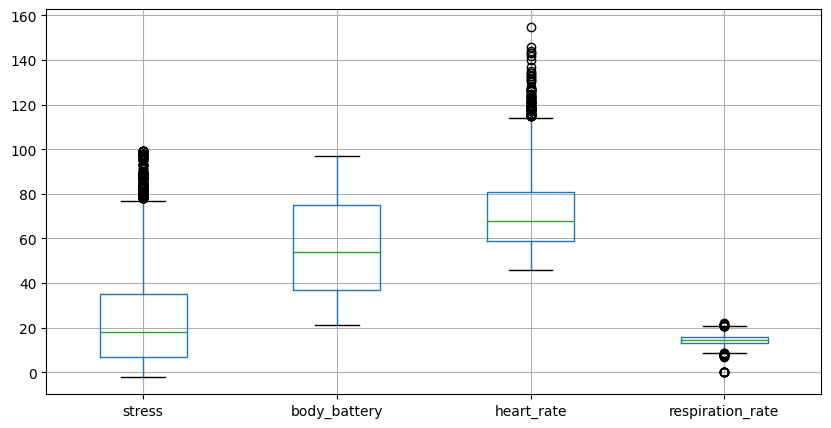

In [43]:
full_df[physiological_features].boxplot(figsize=(10,5))
plt.show()

Group Statistics: We quantify differences in central tendency and variability between cognitive and non-cognitive states.

In [40]:
# Compare average physiological signals between classes
full_df.groupby("is_cognitive")[physiological_features].mean()

,stress,body_battery,heart_rate,respiration_rate
is_cognitive,,,,
0,20.895105,55.045070,72.430516,14.484468
1,37.269430,61.066167,69.929461,14.141880


In [41]:
# Compare variability (standard deviation) between classes
full_df.groupby("is_cognitive")[physiological_features].agg(["mean", "std"])

stress            body_battery            heart_rate  \
                   mean        std         mean        std       mean   
is_cognitive                                                            
0             20.895105  24.648711    55.045070  23.300538  72.430516   
1             37.269430  15.614269    61.066167  13.397644  69.929461   

                        respiration_rate            
                    std             mean       std  
is_cognitive                                        
0             18.442883        14.484468  2.396501  
1              6.732256        14.141880  2.833388

Distribution Shape: We evaluate separability of classes by inspecting distribution overlap.

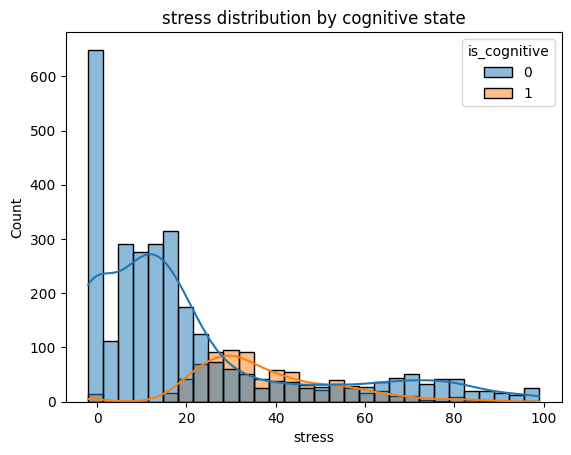

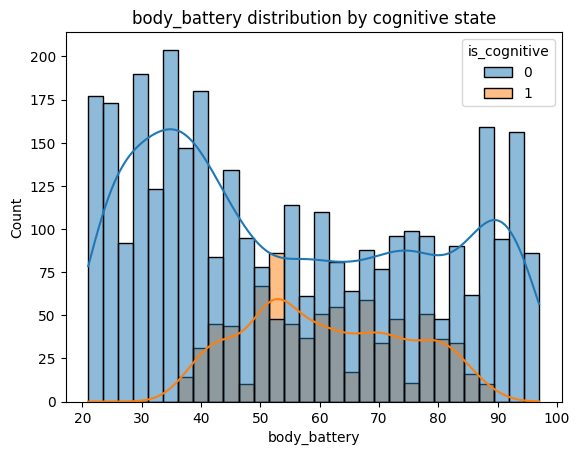

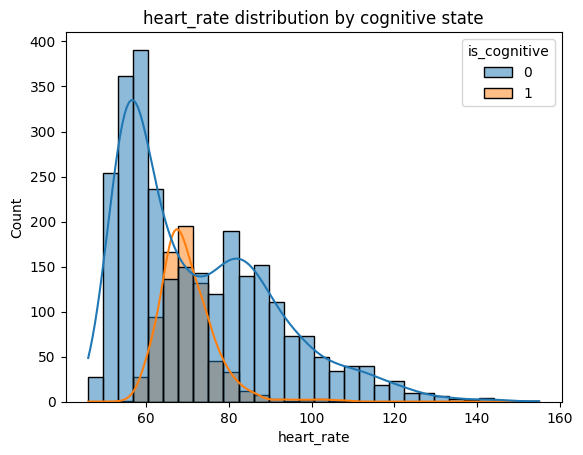

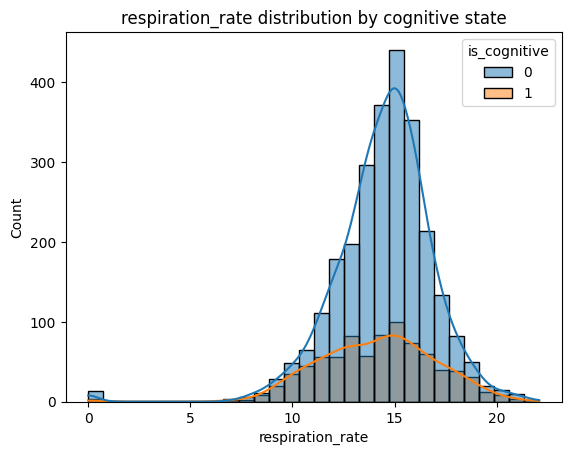

In [42]:
# Check overlap between distributions using histograms
for col in features:
    plt.figure()
    sns.histplot(
        data=full_df,
        x=col,
        hue="is_cognitive",
        kde=True,
        bins=30
    )
    plt.title(f"{col} distribution by cognitive state")
    plt.show()

Effect Size: COHEN’S D (We compute effect sizes to quantify how strongly physiological signals differ between conditions.)

In [44]:
from statistics import mean, stdev
from math import sqrt

def cohens_d(x1, x0):
    return (mean(x1) - mean(x0)) / sqrt((stdev(x1)**2 + stdev(x0)**2) / 2)

for col in features:
    group1 = full_df.loc[full_df["is_cognitive"] == 1, col].dropna()
    group0 = full_df.loc[full_df["is_cognitive"] == 0, col].dropna()
    
    d = cohens_d(group1, group0)
    print(col, d)

stress 0.7936347585599862
body_battery 0.3168095166652053
heart_rate -0.18015520476871552
respiration_rate -0.13055679566221315


Time-of-day bias

In [49]:
full_df["timestamp"] = pd.to_datetime(full_df["timestamp"])

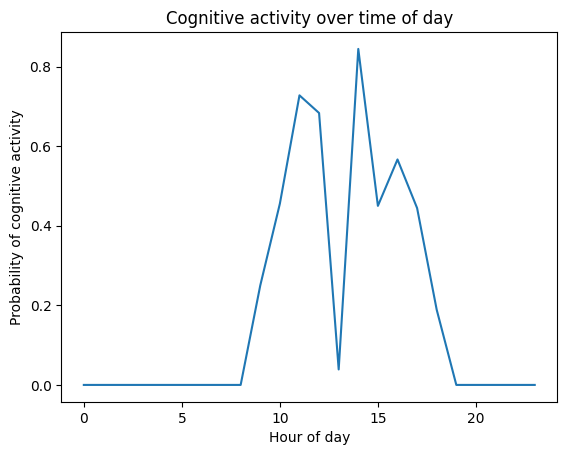

In [ ]:
# Checking whether  the cognitive tasks are concentrated at specific hours??
full_df["hour"] = full_df["timestamp"].dt.hour

full_df.groupby("hour")["is_cognitive"].mean().plot()
plt.title("Cognitive activity over time of day")
plt.xlabel("Hour of day")
plt.ylabel("Probability of cognitive activity")
plt.show()

Activity confounding check: in order to prove that  signals are not just sedentary vs active classification!!

In [ ]:
# Checking whether cognitive periods overlap with specific activities
pd.crosstab(full_df["activity_type"], full_df["is_cognitive"]) 


is_cognitive,0,1
activity_type,,
cycling,166,0
generic,1010,560
running,13,1
sedentary,1892,276
unknown,34,0
walking,186,0


Correlation analysis

In [53]:
# Checking correlation between physiological signals and cognitive state
corr = full_df[physiological_features + ["is_cognitive"]].corr()
corr["is_cognitive"].sort_values()

heart_rate         -0.060371
respiration_rate   -0.057893
body_battery        0.109171
stress              0.275049
is_cognitive        1.000000
Name: is_cognitive, dtype: float64

Missingness vs target: to check if missing data is biased toward one class

In [55]:
# Checking if missing data is biased toward one class
full_df.isna().groupby(full_df["is_cognitive"]).mean()

,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive,hour
is_cognitive,,,,,,,,
0,0.0,0.137812,0.050818,0.239736,0.198392,0.052254,0.0,0.0
1,0.0,0.077658,0.043011,0.027479,0.136201,0.000000,0.0,0.0


Time plots:

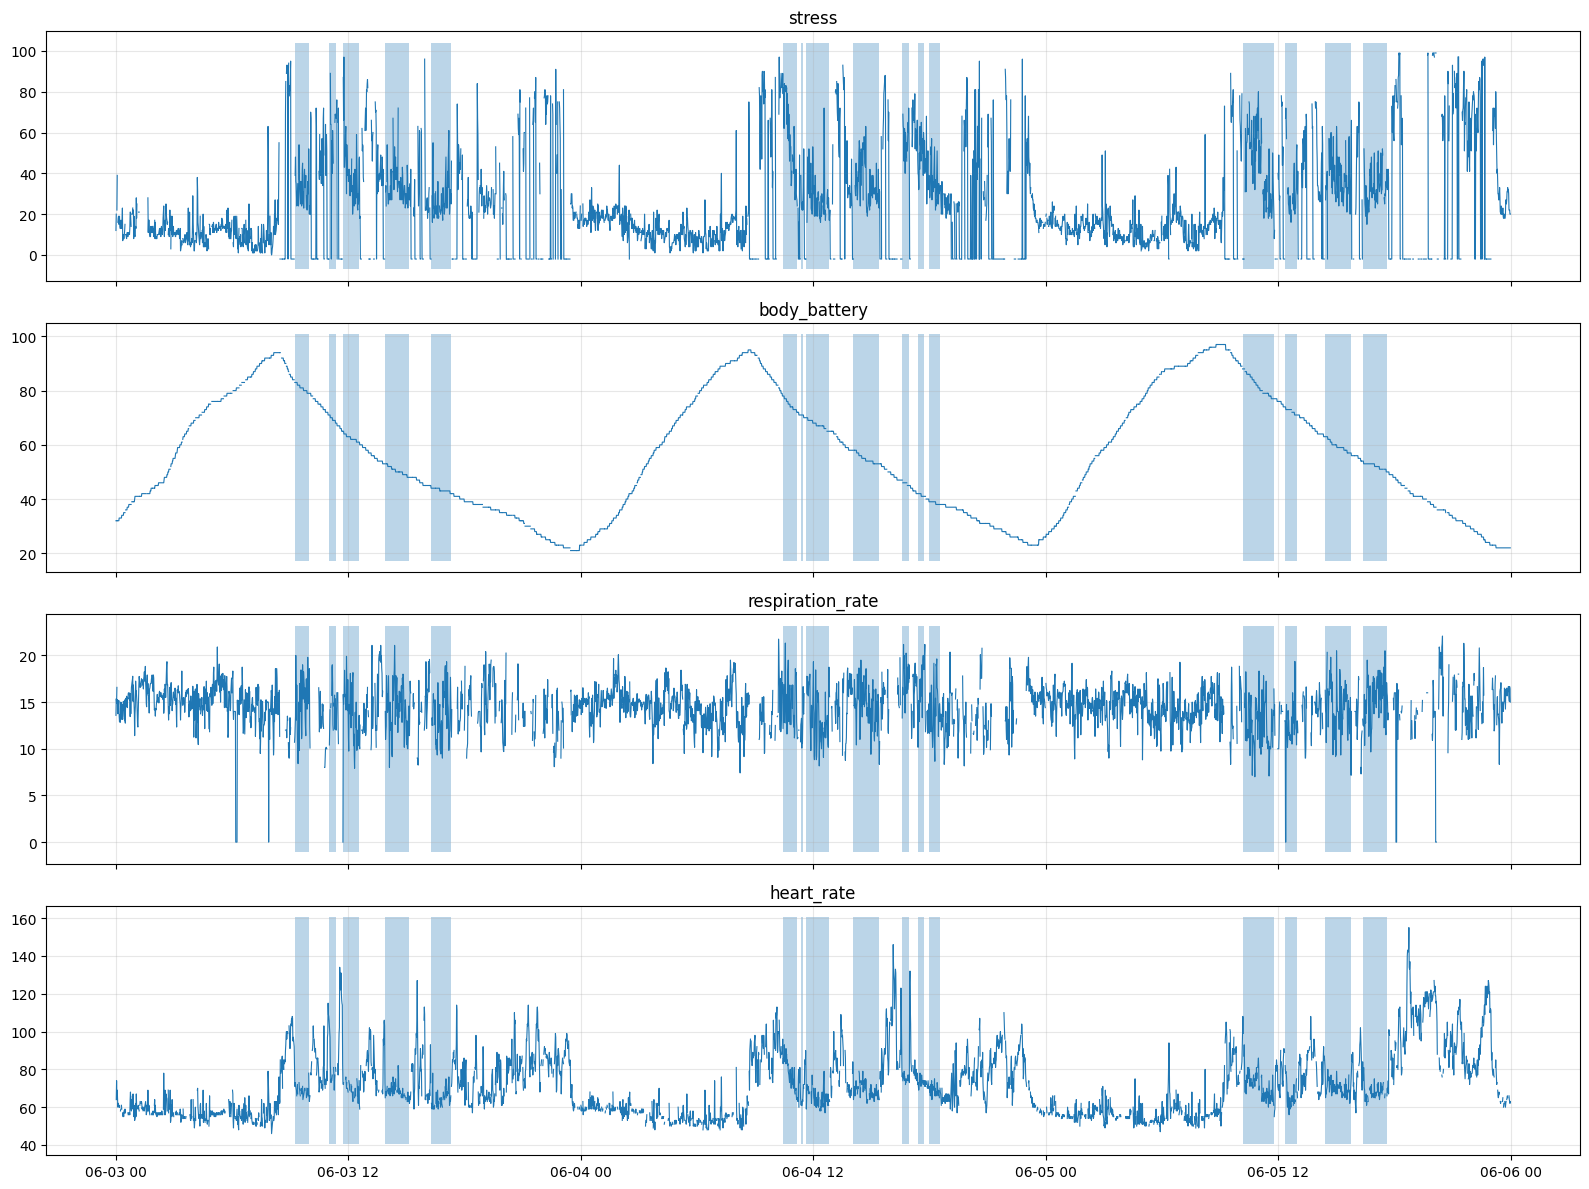

In [57]:
full_df["timestamp"] = pd.to_datetime(full_df["timestamp"])

fig, axes = plt.subplots(
    4, 1,
    figsize=(16, 12),
    sharex=True
)

features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

for ax, feature in zip(axes, features):

    ax.plot(
        full_df["timestamp"],
        full_df[feature],
        linewidth=0.8
    )

    # shade cognitive periods
    cognitive = full_df["is_cognitive"] == 1

    ax.fill_between(
        full_df["timestamp"],
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        where=cognitive,
        alpha=0.3
    )

    ax.set_title(feature)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

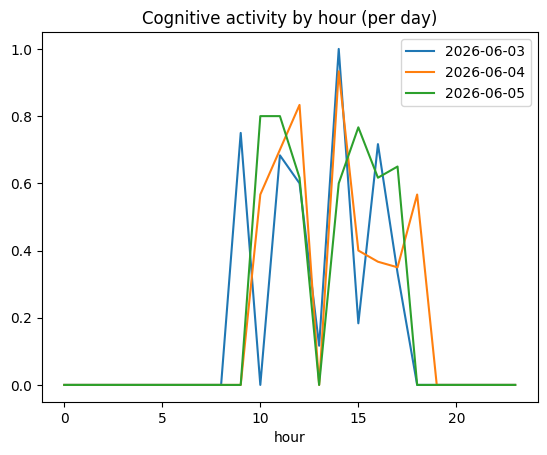

In [59]:
# Compare cognitive activity patterns per day
full_df["date"] = full_df["timestamp"].dt.date

for d in full_df["date"].unique():
    temp = full_df[full_df["date"] == d]
    
    temp.groupby("hour")["is_cognitive"].mean().plot(label=str(d))

plt.legend()
plt.title("Cognitive activity by hour (per day)")
plt.show()

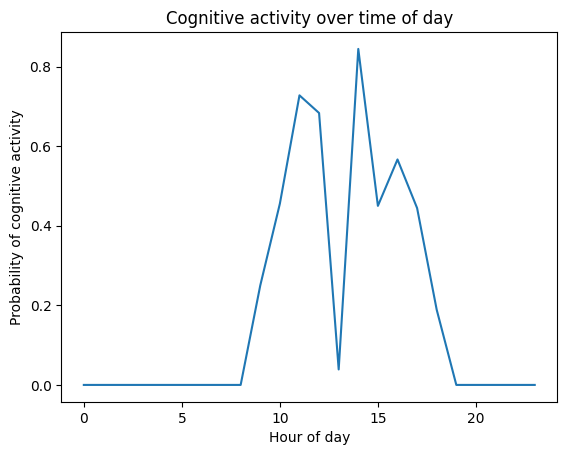

In [60]:
# Check whether cognitive tasks are concentrated at specific hours -> Average probability of cognitive activity at each hour across all 3 days
full_df["hour"] = full_df["timestamp"].dt.hour

full_df.groupby("hour")["is_cognitive"].mean().plot()
plt.title("Cognitive activity over time of day")
plt.xlabel("Hour of day")
plt.ylabel("Probability of cognitive activity")
plt.show()